In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [6]:
print(df)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.shape

(7043, 21)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [15]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
churn_rate

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

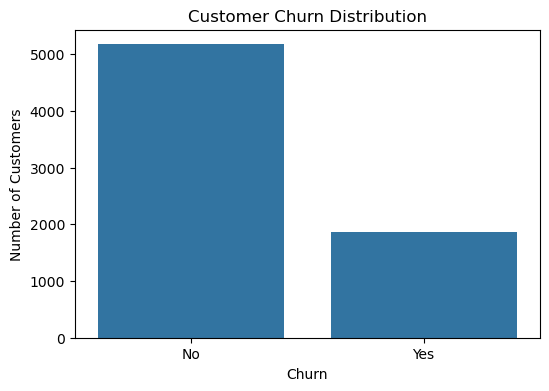

In [16]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [19]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


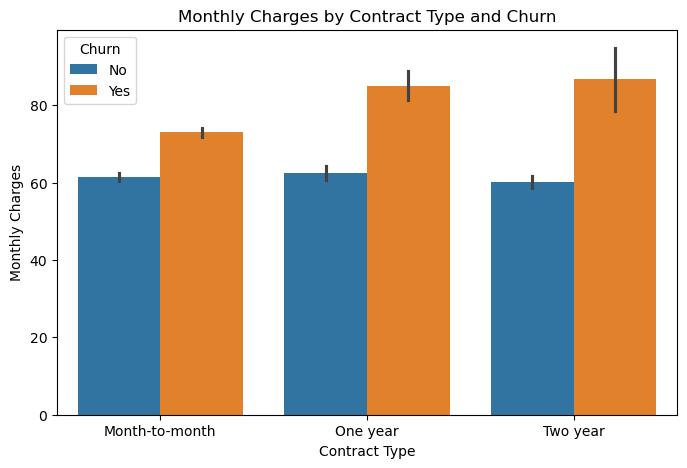

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Contract",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("Monthly Charges by Contract Type and Churn")
plt.xlabel("Contract Type")
plt.ylabel("Monthly Charges")

plt.show()

In [ ]:
### Insight: Contract Type and Customer Churn

Month-to-month customers have the highest churn rate at 42.71%, 
while one-year and two-year contract customers have substantially 
lower churn rates of 11.27% and 2.83%, respectively.

This indicates a strong association between contract type and customer 
retention. Month-to-month customers should therefore be considered 
a high-priority segment for retention strategies.

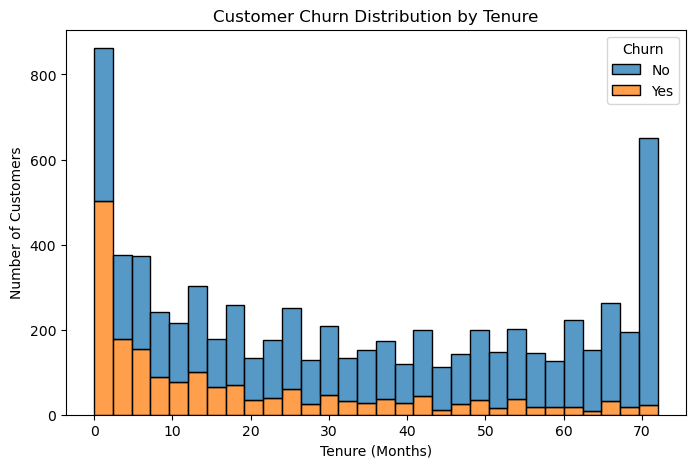

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    multiple="stack"
)

plt.title("Customer Churn Distribution by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [22]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=["0-6 months", "7-12 months", "13-24 months", "25-48 months", "49-72 months"],
    include_lowest=True
)

In [23]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-6 months,47.062795,52.937205
7-12 months,64.113475,35.886525
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


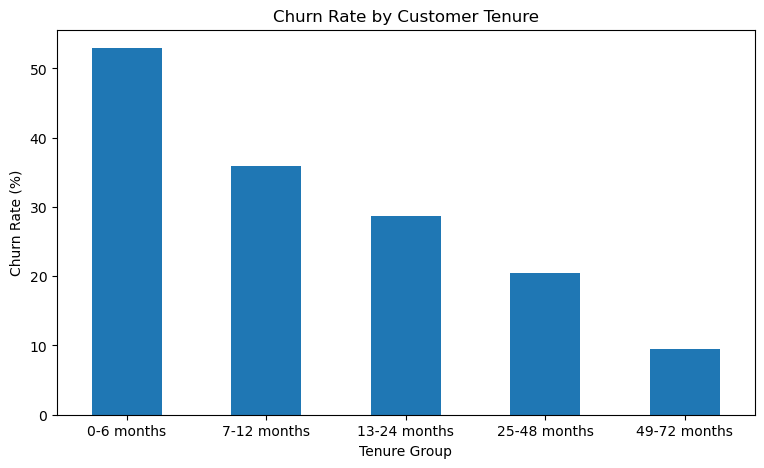

In [24]:
plt.figure(figsize=(9, 5))

tenure_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Insight: Customer Tenure and Churn

Customer churn decreases consistently as tenure increases. 
Customers with 0–6 months of tenure have the highest churn rate 
at 52.94%, while customers with 49–72 months of tenure have the 
lowest churn rate at 9.51%.

This indicates that early-tenure customers represent a high-risk 
segment and may benefit from targeted onboarding and retention 
strategies.

In [25]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


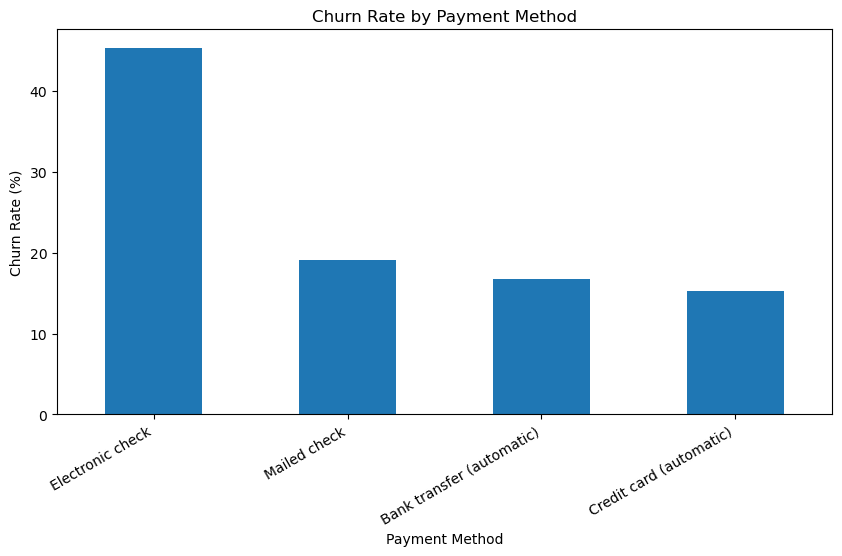

In [26]:
plt.figure(figsize=(10, 5))

payment_churn["Yes"].sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")

plt.show()

### Insight: Payment Method and Churn

Electronic check customers have the highest churn rate at 45.29%,
compared with 19.11% for mailed check, 16.71% for automatic bank
transfer, and 15.24% for automatic credit card payments.

This indicates that electronic check customers represent a
high-risk segment. Further analysis is required to determine whether
payment method itself is associated with churn or whether other
customer characteristics contribute to this pattern.

In [27]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


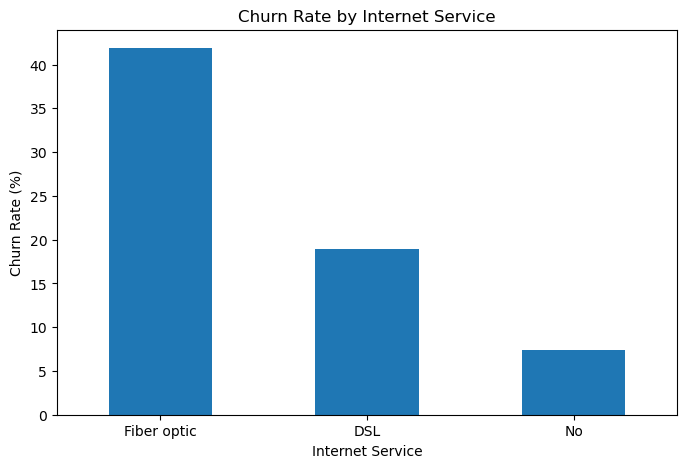

In [28]:
plt.figure(figsize=(8, 5))

internet_churn["Yes"].sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Insight: Internet Service and Churn

Fiber-optic customers have the highest churn rate at 41.89%, 
followed by DSL customers at 18.96%. Customers without internet 
service have the lowest churn rate at 7.40%.

This indicates a strong association between internet service type 
and customer churn. Further analysis of monthly charges, contract 
type, and tenure is required to understand the factors contributing 
to the higher churn among fiber-optic customers.

high_risk = pd.crosstab(
    [df["Contract"], df["InternetService"]],
    df["Churn"],
    normalize="index"
) * 100

high_risk

In [30]:
high_risk["Yes"].sort_values(ascending=False)

Contract        InternetService
Month-to-month  Fiber optic        54.605263
                DSL                32.215863
One year        Fiber optic        19.294991
Month-to-month  No                 18.893130
One year        DSL                 9.298246
Two year        Fiber optic         7.226107
One year        No                  2.472527
Two year        DSL                 1.910828
                No                  0.783699
Name: Yes, dtype: float64

In [32]:
### Insight: Contract and Internet Service Segmentation

Combining contract type and internet service reveals distinct
high-risk customer segments.

Month-to-month customers using fiber-optic internet have the highest
churn rate at 54.61%, followed by month-to-month DSL customers at
32.22%. In contrast, two-year contract customers show substantially
lower churn across all internet service categories, with the lowest
rate of 0.78% among customers without internet service.

This indicates that the combination of contract type and internet
service is strongly associated with customer churn and can be used
to identify high-risk customer segments for further analysis.

Further analysis of tenure, monthly charges, and payment method can
help explain the characteristics of these high-risk segments.

SyntaxError: invalid syntax (343205361.py, line 3)

In [33]:
df["TotalCharges"].dtype

dtype('O')

In [34]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [35]:
df["TotalCharges"].value_counts().head()

TotalCharges
20.2     11
         11
19.75     9
19.65     8
19.9      8
Name: count, dtype: int64

In [36]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [37]:
(df["TotalCharges"].str.strip() == "").sum()

np.int64(11)

In [38]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].str.strip(),
    errors="coerce"
)

In [39]:
df["TotalCharges"].dtype

dtype('float64')

In [40]:
df["TotalCharges"].isna().sum()


np.int64(11)

In [41]:
df[df["TotalCharges"].isna()][
    ["customerID", "tenure", "MonthlyCharges", "Contract", "Churn"]
]

,customerID,tenure,MonthlyCharges,Contract,Churn
488,4472-LVYGI,0,52.55,Two year,No
753,3115-CZMZD,0,20.25,Two year,No
936,5709-LVOEQ,0,80.85,Two year,No
1082,4367-NUYAO,0,25.75,Two year,No
1340,1371-DWPAZ,0,56.05,Two year,No
3331,7644-OMVMY,0,19.85,Two year,No
3826,3213-VVOLG,0,25.35,Two year,No
4380,2520-SGTTA,0,20.00,Two year,No
5218,2923-ARZLG,0,19.70,One year,No
6670,4075-WKNIU,0,73.35,Two year,No


In [42]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [43]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [44]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].head()

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


### Data Cleaning: Total Charges

The `TotalCharges` column was initially stored as an object/string
datatype and contained 11 blank values.

Investigation showed that all 11 records had a tenure of 0 months,
indicating newly joined customers with no accumulated charges.

The column was converted to numeric format, and the 11 missing
`TotalCharges` values were replaced with 0 rather than removing
the records. This preserves all customer records while maintaining
a logically consistent representation of total charges.

In [45]:
revenue_by_churn = df.groupby("Churn")["TotalCharges"].sum()

revenue_by_churn

Churn
No     13193241.8
Yes     2862926.9
Name: TotalCharges, dtype: float64

In [46]:
total_revenue = df["TotalCharges"].sum()

churned_revenue = df.loc[
    df["Churn"] == "Yes",
    "TotalCharges"
].sum()

revenue_at_risk_pct = (churned_revenue / total_revenue) * 100

print("Total revenue:", total_revenue)
print("Churned customer revenue:", churned_revenue)
print("Revenue associated with churned customers (%):", revenue_at_risk_pct)

Total revenue: 16056168.7
Churned customer revenue: 2862926.9
Revenue associated with churned customers (%): 17.830697680698883


### Insight: Revenue Associated with Churn

Customers who churned account for ₹2,862,926.90 in historical
customer charges, representing approximately 17.83% of the total
₹16,056,168.70 in customer charges in the dataset.

While 26.54% of customers have churned, their share of historical
charges is lower at 17.83%. This indicates that churn is not evenly
distributed across customers and motivates further analysis of
customer value and revenue patterns among churned customers.

Note: TotalCharges represents historical charges accumulated during
customer tenure, so this metric should not be interpreted as
forecasted future revenue loss.

In [47]:
high_value_churn = df[df["Churn"] == "Yes"].sort_values(
    "TotalCharges",
    ascending=False
)

high_value_churn[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "InternetService",
        "PaymentMethod"
    ]
].head(10)

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod
4610,2889-FPWRM,72,117.80,8684.80,One year,Fiber optic,Bank transfer (automatic)
1306,0201-OAMXR,70,115.55,8127.60,One year,Fiber optic,Credit card (automatic)
3890,3886-CERTZ,72,109.25,8109.80,One year,Fiber optic,Electronic check
6537,1444-VVSGW,70,115.65,7968.85,One year,Fiber optic,Credit card (automatic)
5581,5271-YNWVR,68,113.15,7856.00,Two year,Fiber optic,Electronic check
5127,8199-ZLLSA,67,118.35,7804.15,One year,Fiber optic,Bank transfer (automatic)
6289,9053-JZFKV,67,116.20,7752.30,Two year,Fiber optic,Credit card (automatic)
6038,1555-DJEQW,70,114.20,7723.90,Two year,Fiber optic,Bank transfer (automatic)
6398,3259-FDWOY,71,106.00,7723.70,Two year,Fiber optic,Bank transfer (automatic)
3040,7317-GGVPB,71,108.60,7690.90,Two year,Fiber optic,Credit card (automatic)


### Insight: High-Value Churned Customers

The highest-value churned customers by historical TotalCharges had
long tenures of 67–72 months and monthly charges between ₹106 and ₹118.
All 10 customers in the top-10 list used fiber-optic internet.

Most of these customers were on one-year or two-year contracts,
showing that churn can also occur among long-tenure and relatively
high-value customers.

This suggests that retention analysis should not focus only on
high-churn segments. Identifying valuable customers who eventually
churn can help prioritize retention efforts based on both churn risk
and customer value.

In [48]:
high_value_threshold = df["TotalCharges"].quantile(0.75)

print("High-value threshold:", high_value_threshold)

High-value threshold: 3786.6


In [49]:
high_value_churned = df[
    (df["TotalCharges"] >= high_value_threshold) &
    (df["Churn"] == "Yes")
]

print("High-value churned customers:", len(high_value_churned))

High-value churned customers: 255


In [50]:
high_value_churn_rate = (
    len(high_value_churned) /
    len(df[df["TotalCharges"] >= high_value_threshold])
) * 100

print("High-value customer churn rate:", high_value_churn_rate)

High-value customer churn rate: 14.480408858603067


### Insight: High-Value Customer Churn

Customers with TotalCharges of ₹3,786.60 or more were classified as
high-value customers using the 75th percentile as the threshold.

Among these high-value customers, 255 had churned, corresponding to
a churn rate of 14.48%. This is substantially lower than the overall
customer churn rate of 26.54%.

This indicates that high-value customers in the dataset have a lower
observed churn rate than the overall customer base. However, because
some high-value customers still churn, customer value and churn risk
should be considered together when prioritizing retention strategies.

In [51]:
monthly_charges_churn = df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "sum"]
)

monthly_charges_churn

,count,mean,median,sum
Churn,,,,
No,5174,61.265124,64.425,316985.75
Yes,1869,74.441332,79.650,139130.85


In [52]:
print("Average monthly charge - Churned:",
      df.loc[df["Churn"] == "Yes", "MonthlyCharges"].mean())

print("Average monthly charge - Retained:",
      df.loc[df["Churn"] == "No", "MonthlyCharges"].mean())

Average monthly charge - Churned: 74.44133226324237
Average monthly charge - Retained: 61.26512369540008


### Insight: Monthly Charges and Churn

Churned customers have higher monthly charges than retained
customers. The average monthly charge for churned customers is
₹74.44, compared with ₹61.27 for retained customers, while the
median monthly charges are ₹79.65 and ₹64.43 respectively.

This indicates that customers who churn tend to have higher
recurring monthly charges. Therefore, churn risk combined with
monthly revenue can be useful for prioritizing retention efforts.

However, this is an observed association and does not establish
that higher monthly charges cause customers to churn.

In [53]:
monthly_charge_threshold = df["MonthlyCharges"].quantile(0.75)

print("High monthly-charge threshold:", monthly_charge_threshold)

High monthly-charge threshold: 89.85


In [54]:
high_monthly_churn = df[
    (df["MonthlyCharges"] >= monthly_charge_threshold) &
    (df["Churn"] == "Yes")
]

print("High monthly-charge churned customers:", len(high_monthly_churn))

High monthly-charge churned customers: 580


In [55]:
high_monthly_churn_rate = (
    len(high_monthly_churn) /
    len(df[df["MonthlyCharges"] >= monthly_charge_threshold])
) * 100

print("High monthly-charge customer churn rate:",
      high_monthly_churn_rate)

High monthly-charge customer churn rate: 32.74985883681536


### Insight: High Monthly-Charge Customers and Churn

Customers with MonthlyCharges of 89.85 or more were classified as
high monthly-charge customers using the 75 th percentile as the
threshold.

Among these customers, 580 had churned, corresponding to an observed
churn rate of 32.75%. This is 6.21 percentage points higher than the
overall customer churn rate of 26.54%.

This indicates that customers with higher recurring monthly charges
have a higher observed churn rate in the dataset. Combining monthly
revenue with churn risk can therefore help prioritize retention
efforts.

However, this relationship is observational and does not establish
that higher monthly charges cause customers to churn.

In [59]:
high_risk_revenue = df[
    (df["Contract"] == "Month-to-month") &
    (df["InternetService"] == "Fiber optic") &
    (df["MonthlyCharges"] >= monthly_charge_threshold)
]

high_risk_revenue_churn = (
    high_risk_revenue["Churn"]
    .value_counts(normalize=True) * 100
)

high_risk_revenue_churn

Churn
Yes    51.995439
No     48.004561
Name: proportion, dtype: float64

In [60]:
print("Customers in segment:", len(high_risk_revenue))

print(
    "Churned customers:",
    (high_risk_revenue["Churn"] == "Yes").sum()
)

print(
    "Average monthly charge:",
    high_risk_revenue["MonthlyCharges"].mean()
)

Customers in segment: 877
Churned customers: 456
Average monthly charge: 98.2984606613455


In [61]:
high_risk_revenue = df[
    (df["Contract"] == "Month-to-month") &
    (df["InternetService"] == "Fiber optic") &
    (df["MonthlyCharges"] >= monthly_charge_threshold)
]

high_risk_revenue_churn = (
    high_risk_revenue["Churn"]
    .value_counts(normalize=True) * 100
)

high_risk_revenue_churn

Churn
Yes    51.995439
No     48.004561
Name: proportion, dtype: float64

In [62]:
print("Customers in segment:", len(high_risk_revenue))

print(
    "Churned customers:",
    (high_risk_revenue["Churn"] == "Yes").sum()
)

print(
    "Average monthly charge:",
    high_risk_revenue["MonthlyCharges"].mean()
)

Customers in segment: 877
Churned customers: 456
Average monthly charge: 98.2984606613455


In [63]:
high_risk_revenue = df[
    (df["Contract"] == "Month-to-month") &
    (df["InternetService"] == "Fiber optic") &
    (df["MonthlyCharges"] >= monthly_charge_threshold)
]

print("Customers in segment:", len(high_risk_revenue))
print("Churned customers:", (high_risk_revenue["Churn"] == "Yes").sum())
print("Churn rate:",
      (high_risk_revenue["Churn"] == "Yes").mean() * 100)
print("Average monthly charge:",
      high_risk_revenue["MonthlyCharges"].mean())
print("Total monthly charges:",
      high_risk_revenue["MonthlyCharges"].sum())

Customers in segment: 877
Churned customers: 456
Churn rate: 51.995438996579246
Average monthly charge: 98.2984606613455
Total monthly charges: 86207.75


In [64]:
segment_analysis = (
    df.groupby(["Contract", "InternetService"])
      .agg(
          Customers=("customerID", "count"),
          Churned=("Churn", lambda x: (x == "Yes").sum()),
          Churn_Rate=("Churn", lambda x: (x == "Yes").mean() * 100),
          Avg_Monthly_Charges=("MonthlyCharges", "mean"),
          Total_Monthly_Charges=("MonthlyCharges", "sum")
      )
      .reset_index()
)

segment_analysis = segment_analysis.sort_values(
    "Churn_Rate",
    ascending=False
)

segment_analysis

,Contract,InternetService,Customers,Churned,Churn_Rate,Avg_Monthly_Charges,Total_Monthly_Charges
1,Month-to-month,Fiber optic,2128,1162,54.605263,87.021194,185181.10
0,Month-to-month,DSL,1223,394,32.215863,50.219501,61418.45
4,One year,Fiber optic,539,104,19.294991,98.779499,53242.15
2,Month-to-month,No,524,99,18.893130,20.409542,10694.60
3,One year,DSL,570,53,9.298246,61.396754,34996.15
7,Two year,Fiber optic,429,31,7.226107,104.571445,44861.15
5,One year,No,364,9,2.472527,20.819505,7578.30
6,Two year,DSL,628,12,1.910828,70.462978,44250.75
8,Two year,No,638,5,0.783699,21.777351,13893.95


In [65]:
segment_analysis["Priority"] = np.where(
    segment_analysis["Churn_Rate"] >= 40,
    "High",
    np.where(
        segment_analysis["Churn_Rate"] >= 20,
        "Medium",
        "Low"
    )
)

segment_analysis

,Contract,InternetService,Customers,Churned,Churn_Rate,Avg_Monthly_Charges,Total_Monthly_Charges,Priority
1,Month-to-month,Fiber optic,2128,1162,54.605263,87.021194,185181.10,High
0,Month-to-month,DSL,1223,394,32.215863,50.219501,61418.45,Medium
4,One year,Fiber optic,539,104,19.294991,98.779499,53242.15,Low
2,Month-to-month,No,524,99,18.893130,20.409542,10694.60,Low
3,One year,DSL,570,53,9.298246,61.396754,34996.15,Low
7,Two year,Fiber optic,429,31,7.226107,104.571445,44861.15,Low
5,One year,No,364,9,2.472527,20.819505,7578.30,Low
6,Two year,DSL,628,12,1.910828,70.462978,44250.75,Low
8,Two year,No,638,5,0.783699,21.777351,13893.95,Low


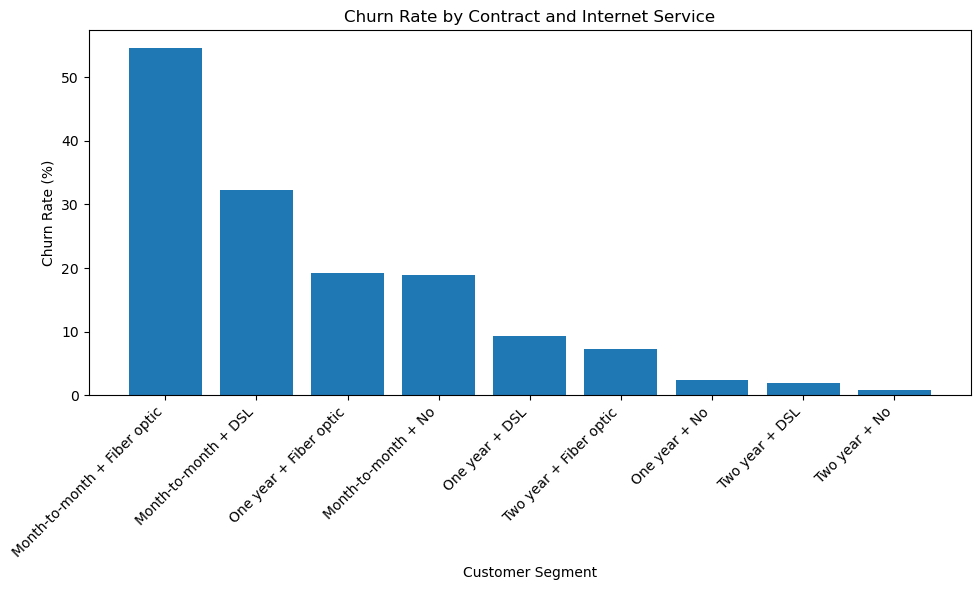

In [66]:
plt.figure(figsize=(10, 6))

segment_labels = (
    segment_analysis["Contract"] + " + " +
    segment_analysis["InternetService"]
)

plt.bar(
    segment_labels,
    segment_analysis["Churn_Rate"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Customer Segment")
plt.title("Churn Rate by Contract and Internet Service")
plt.tight_layout()
plt.show()